# Factor Models: From Risk Reports to Regressions

By the end of this notebook you will understand **every number** on a factor risk report — beta, alpha, R-squared, factor loadings, information ratio — and you will be able to compute them yourself.

We will work with real market data, run real regressions, and build the same intuition your risk desk uses every morning. Think of this as a senior quant walking you through the math over coffee.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import yfinance as yf
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

TRADING_DAYS = 252

In [3]:
# Fetch daily prices for our universe
tickers = ['SPY', 'AAPL', 'JPM', 'XOM']
prices = yf.download(tickers, start='2020-01-01', end='2025-01-01', progress=False)['Close']
returns = prices.pct_change().dropna()
print(f'Loaded {len(returns)} trading days from {returns.index[0].date()} to {returns.index[-1].date()}')

Loaded 1257 trading days from 2020-01-03 to 2024-12-31


In [4]:
# Quick sanity check — what do these returns look like?
returns.describe().round(4)

Ticker,AAPL,JPM,SPY,XOM
count,1257.0000,1257.0000,1257.0000,1257.0000
mean,0.0012,0.0007,0.0006,0.0008
std,0.0200,0.0205,0.0132,0.0217
min,-0.1286,-0.1496,-0.1094,-0.1222
25%,-0.0084,-0.0084,-0.0051,-0.0109
50%,0.0012,0.0007,0.0009,0.0002
75%,0.0120,0.0099,0.0073,0.0121
max,0.1198,0.1801,0.0906,0.1269


## Section 2: Beta — How Much Does Your Stock Move With the Market?

Beta is the simplest concept in factor modeling and the one you already use every day. If SPY goes up 1% and AAPL goes up 1.3%, AAPL's beta is roughly 1.3. It amplifies market moves by 30%.

The best way to see this is a scatter plot. Each dot is one trading day — SPY return on the x-axis, AAPL return on the y-axis. The slope of the best-fit line **is** beta.

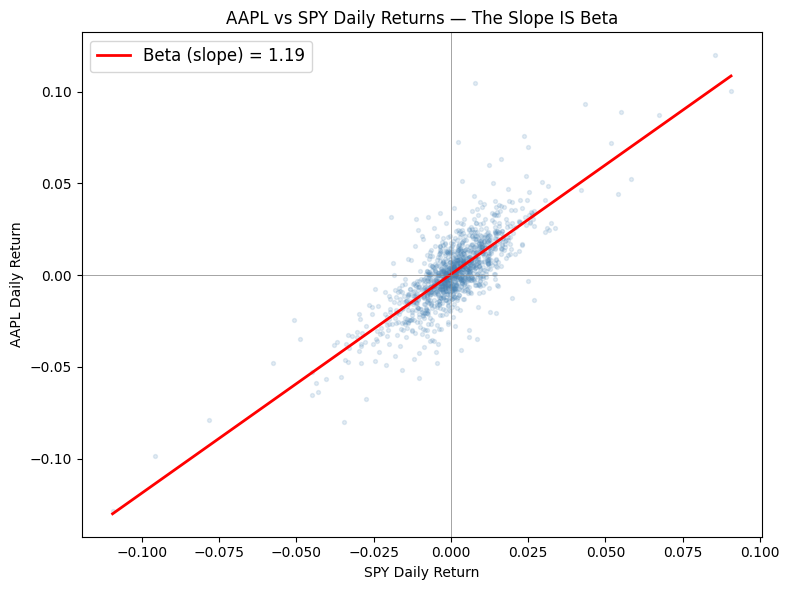

In [5]:
# Scatter plot: AAPL vs SPY daily returns with regression line
x = returns['SPY'].values
y = returns['AAPL'].values

slope, intercept = np.polyfit(x, y, 1)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x, y, alpha=0.15, s=8, color='steelblue')
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(x_line, slope * x_line + intercept, color='red', linewidth=2,
        label=f'Beta (slope) = {slope:.2f}')
ax.axhline(0, color='grey', linewidth=0.5)
ax.axvline(0, color='grey', linewidth=0.5)
ax.set_xlabel('SPY Daily Return')
ax.set_ylabel('AAPL Daily Return')
ax.set_title('AAPL vs SPY Daily Returns \u2014 The Slope IS Beta')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

That slope is beta. When SPY moves 1%, AAPL tends to move roughly that many percent in the same direction. The scatter is wide — beta does not explain everything — but the relationship is clearly there.

Now let's get the full regression stats using OLS.

In [6]:
# Full OLS regression: AAPL = alpha + beta * SPY + noise
X = sm.add_constant(returns['SPY'])
model_simple = sm.OLS(returns['AAPL'], X).fit()
print(model_simple.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.625
Model:                            OLS   Adj. R-squared:                  0.625
Method:                 Least Squares   F-statistic:                     2092.
Date:                Fri, 06 Mar 2026   Prob (F-statistic):          1.23e-269
Time:                        13:00:11   Log-Likelihood:                 3753.7
No. Observations:                1257   AIC:                            -7503.
Df Residuals:                    1255   BIC:                            -7493.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      1.290      0.1

Key numbers from this output:

- **Beta** (the SPY coefficient): how much AAPL moves per 1% SPY move
- **R-squared**: what fraction of AAPL's daily variance is explained by the market alone
- **Intercept** (alpha): the daily return AAPL earned beyond its market exposure
- **t-stat on the intercept**: is that alpha statistically significant, or just noise?

In [7]:
# EXERCISE: Replace 'AAPL' with 'XOM' below and re-run this cell.
# How does XOM's beta compare? Is it more or less sensitive to the market?

stock = 'AAPL'  # <-- change this to 'XOM' or 'JPM'

X_ex = sm.add_constant(returns['SPY'])
model_ex = sm.OLS(returns[stock], X_ex).fit()
print(f'{stock} beta: {model_ex.params.iloc[1]:.3f}')
print(f'{stock} R-squared: {model_ex.rsquared:.1%}')

AAPL beta: 1.193
AAPL R-squared: 62.5%


## Section 3: CAPM Regression — The Full Picture

The Capital Asset Pricing Model adds one twist: we use **excess returns** (returns above the risk-free rate). The equation is:

```
R_stock - Rf = alpha + beta * (R_market - Rf) + epsilon
```

This matters because investors could earn the risk-free rate by doing nothing. Alpha should only measure the return **above** that free lunch.

In [8]:
# CAPM with excess returns
annual_rf = 0.05  # ~5% risk-free rate
daily_rf = annual_rf / TRADING_DAYS

excess_spy = returns['SPY'] - daily_rf
excess_aapl = returns['AAPL'] - daily_rf

X_capm = sm.add_constant(excess_spy)
capm_model = sm.OLS(excess_aapl, X_capm).fit()

alpha_annual = capm_model.params.iloc[0] * TRADING_DAYS
beta = capm_model.params.iloc[1]
alpha_tstat = capm_model.tvalues.iloc[0]

print('AAPL CAPM Results')
print(f'  Alpha (annual): {alpha_annual:.2%}  (t-stat: {alpha_tstat:.2f})')
print(f'  Beta:           {beta:.3f}')
print(f'  R-squared:      {capm_model.rsquared:.1%}')
sig = 'Yes' if abs(alpha_tstat) > 2 else 'No \u2014 could be noise'
print(f'  Alpha significant? {sig}')

AAPL CAPM Results
  Alpha (annual): 12.19%  (t-stat: 1.40)
  Beta:           1.193
  R-squared:      62.5%
  Alpha significant? No — could be noise


The alpha t-stat is the number that separates real skill from lucky streaks. A big alpha with a small t-stat means "probably noise." A modest alpha with t > 2 means "probably real." This is exactly what your fund's allocators look at when evaluating PMs.

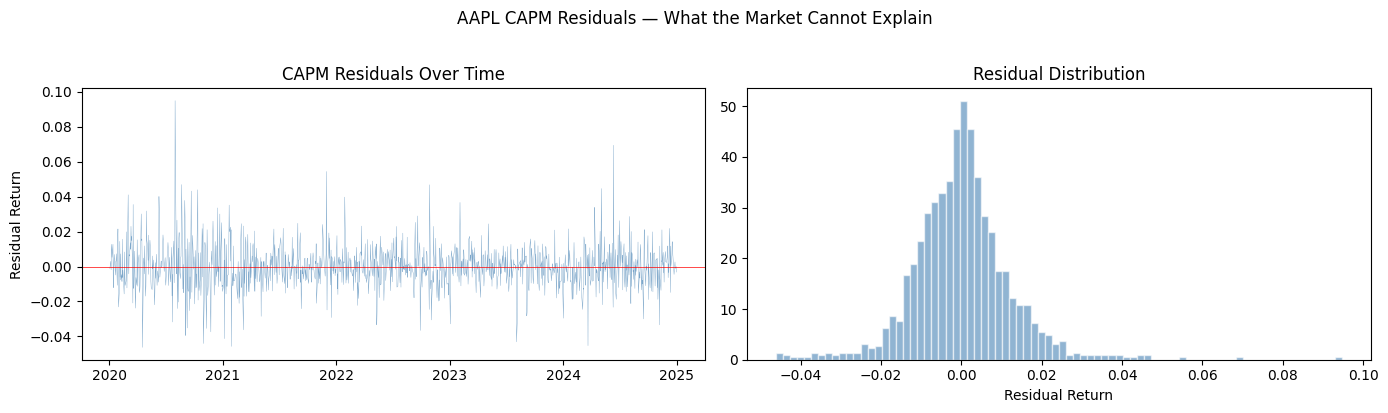

In [9]:
# Residuals: what CAPM can't explain
residuals = capm_model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(residuals, linewidth=0.3, alpha=0.7, color='steelblue')
axes[0].axhline(0, color='red', linewidth=0.5)
axes[0].set_title('CAPM Residuals Over Time')
axes[0].set_ylabel('Residual Return')

axes[1].hist(residuals, bins=80, density=True, alpha=0.6, color='steelblue', edgecolor='white')
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual Return')

plt.suptitle('AAPL CAPM Residuals \u2014 What the Market Cannot Explain', y=1.02)
plt.tight_layout()
plt.show()

## Section 4: Fama-French 3-Factor Model — Why One Factor Isn't Enough

CAPM says the market is the only factor that matters. Fama and French proved that's incomplete. Two more factors explain a big chunk of what CAPM misses:

- **SMB (Small Minus Big)**: small-cap stocks tend to outperform large-caps over time. If your PM is long a bunch of $2B companies, they're loading up on this factor whether they realize it or not.
- **HML (High Minus Low)**: cheap "value" stocks tend to beat expensive "growth" stocks. A PM who loves low P/E names has positive HML exposure.

We'll build rough factor proxies using ETFs: `IWM - SPY` for SMB, `IWD - IWF` for HML.

In [10]:
# Build factor proxies from ETFs
factor_tickers = ['SPY', 'IWM', 'IWD', 'IWF']
factor_prices = yf.download(factor_tickers, start='2020-01-01', end='2025-01-01', progress=False)['Close']
factor_rets = factor_prices.pct_change().dropna()

factors = pd.DataFrame(index=factor_rets.index)
factors['MKT'] = factor_rets['SPY'] - daily_rf
factors['SMB'] = factor_rets['IWM'] - factor_rets['SPY']
factors['HML'] = factor_rets['IWD'] - factor_rets['IWF']

print(f'Factor proxies built: {list(factors.columns)}')
factors.describe().round(4)

Factor proxies built: ['MKT', 'SMB', 'HML']


,MKT,SMB,HML
count,1257.0000,1257.0000,1257.0000
mean,0.0004,-0.0002,-0.0004
std,0.0132,0.0088,0.0095
min,-0.1096,-0.0287,-0.0440
25%,-0.0053,-0.0058,-0.0063
50%,0.0007,-0.0003,-0.0007
75%,0.0071,0.0047,0.0053
max,0.0904,0.0446,0.0587


In [11]:
# 3-factor regression for AAPL
aligned = pd.concat([returns['AAPL'] - daily_rf, factors], axis=1).dropna()
y_ff = aligned.iloc[:, 0]
X_ff = sm.add_constant(aligned[['MKT', 'SMB', 'HML']])

ff_model = sm.OLS(y_ff, X_ff).fit()

capm_r2 = capm_model.rsquared
ff_r2 = ff_model.rsquared

print('AAPL 3-Factor Results')
print(f'  Alpha (annual):  {ff_model.params.iloc[0] * TRADING_DAYS:.2%}')
print(f'  MKT beta:        {ff_model.params["MKT"]:.3f}  (t={ff_model.tvalues["MKT"]:.2f})')
print(f'  SMB loading:     {ff_model.params["SMB"]:.3f}  (t={ff_model.tvalues["SMB"]:.2f})')
print(f'  HML loading:     {ff_model.params["HML"]:.3f}  (t={ff_model.tvalues["HML"]:.2f})')
print()
print(f'  R-squared went from {capm_r2:.1%} (CAPM) to {ff_r2:.1%} (3-factor)')
print(f'  That extra {ff_r2 - capm_r2:.1%} is what SMB and HML explain.')

AAPL 3-Factor Results
  Alpha (annual):  6.78%
  MKT beta:        1.096  (t=44.34)
  SMB loading:     -0.140  (t=-3.67)
  HML loading:     -0.596  (t=-16.67)

  R-squared went from 62.5% (CAPM) to 71.8% (3-factor)
  That extra 9.3% is what SMB and HML explain.


Notice the signs on the factor loadings. A **negative SMB** loading means AAPL acts like a large-cap (it is one). A **negative HML** loading means AAPL acts like a growth stock — when value beats growth, AAPL tends to lag. These loadings tell you *what kind* of risk is embedded in the position.

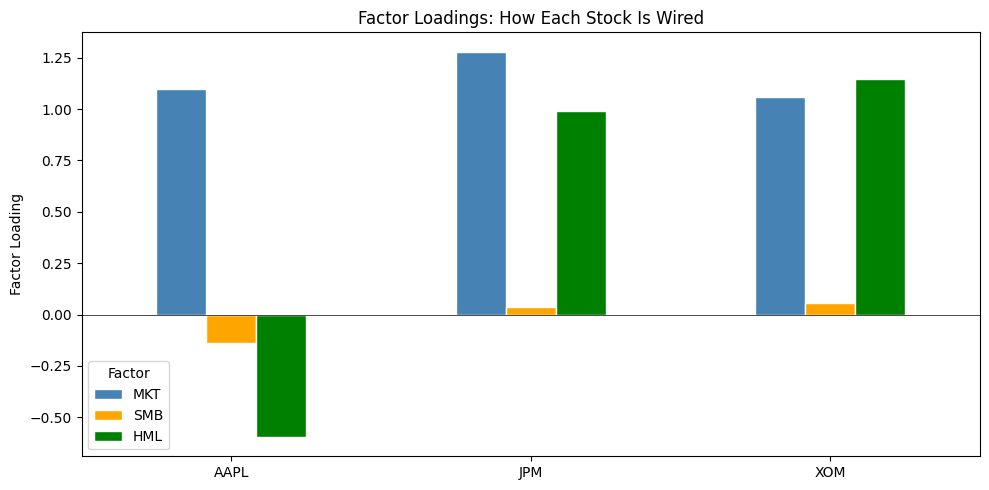

Factor loadings table:
        MKT    SMB    HML
AAPL  1.096 -0.140 -0.596
JPM   1.279  0.038  0.988
XOM   1.060  0.058  1.147


In [12]:
# Compare factor loadings across all three stocks
loadings = {}
for ticker in ['AAPL', 'JPM', 'XOM']:
    aligned_t = pd.concat([returns[ticker] - daily_rf, factors], axis=1).dropna()
    y_t = aligned_t.iloc[:, 0]
    X_t = sm.add_constant(aligned_t[['MKT', 'SMB', 'HML']])
    m = sm.OLS(y_t, X_t).fit()
    loadings[ticker] = {'MKT': m.params['MKT'], 'SMB': m.params['SMB'], 'HML': m.params['HML']}

loadings_df = pd.DataFrame(loadings).T

fig, ax = plt.subplots(figsize=(10, 5))
loadings_df.plot(kind='bar', ax=ax, color=['steelblue', 'orange', 'green'], edgecolor='white')
ax.set_title('Factor Loadings: How Each Stock Is Wired')
ax.set_ylabel('Factor Loading')
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(title='Factor')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Factor loadings table:')
print(loadings_df.round(3).to_string())

## Section 5: Alpha — The Holy Grail (And Why Most of It Is Fake)

Alpha is the return left over after you remove all factor exposure. It's the intercept in the regression — what your PM generated that factors didn't hand them for free.

Here's the uncomfortable truth: most "alpha" disappears when you add more factors. A PM who looks like a genius under CAPM might just be loading up on size and value. Let's see this in action.

In [13]:
# Compare CAPM alpha vs 3-factor alpha for each stock
header = f'{"Stock":<6} {"CAPM Alpha":>12} {"3F Alpha":>12} {"Difference":>12}'
print(header)
print('-' * 46)

for ticker in ['AAPL', 'JPM', 'XOM']:
    # CAPM
    excess_stock = returns[ticker] - daily_rf
    X_c = sm.add_constant(excess_spy)
    aligned_c = pd.concat([excess_stock, X_c], axis=1).dropna()
    capm_m = sm.OLS(aligned_c.iloc[:, 0], aligned_c.iloc[:, 1:]).fit()
    capm_alpha = capm_m.params.iloc[0] * TRADING_DAYS

    # 3-factor
    aligned_f = pd.concat([returns[ticker] - daily_rf, factors], axis=1).dropna()
    ff_m = sm.OLS(aligned_f.iloc[:, 0], sm.add_constant(aligned_f[['MKT', 'SMB', 'HML']])).fit()
    ff_alpha = ff_m.params.iloc[0] * TRADING_DAYS

    diff = capm_alpha - ff_alpha
    print(f'{ticker:<6} {capm_alpha:>11.2%} {ff_alpha:>11.2%} {diff:>11.2%}')

print()
print('The difference is what SMB & HML explained \u2014 not skill, just factor exposure.')

Stock    CAPM Alpha     3F Alpha   Difference
----------------------------------------------
AAPL        12.19%       6.78%       5.41%
JPM          2.23%      10.02%      -7.79%
XOM          5.18%      14.30%      -9.12%

The difference is what SMB & HML explained — not skill, just factor exposure.


That shrinkage is exactly what allocators worry about. An LP doesn't pay 2-and-20 for factor exposure they could get from a Vanguard ETF for 3 bps. They pay for the residual — the part factors **can't** explain. When CAPM alpha shrinks after adding factors, it means the PM's "edge" was really just a tilt toward small-caps or value that could have been replicated cheaply.

In [14]:
# EXERCISE: Add a momentum factor to the model.
# Download MTUM (iShares Momentum ETF) and create MOM = MTUM_returns - SPY_returns.
# Then run a 4-factor regression. Does alpha shrink further? Does R-squared improve?

# mom_prices = yf.download('MTUM', start='2020-01-01', end='2025-01-01', progress=False)['Close']
# mom_returns = mom_prices.pct_change().dropna()
# factors['MOM'] = mom_returns - factor_rets['SPY']  # align carefully!
# ... run 4-factor regression here ...

## Section 6: Rolling Beta — Because Nothing Is Constant

Everything above assumes beta is a fixed number. It isn't. A stock's market sensitivity shifts with regime changes, earnings, sector rotation, and macro events. Rolling beta (typically a 63-day window, about 3 months) shows this drift in real time.

Your risk desk tracks rolling beta to catch PMs who drift away from their mandate. If a PM targets 0.5 beta and slowly drifts to 1.2, that's unintended market risk — the kind that blows up in drawdowns.

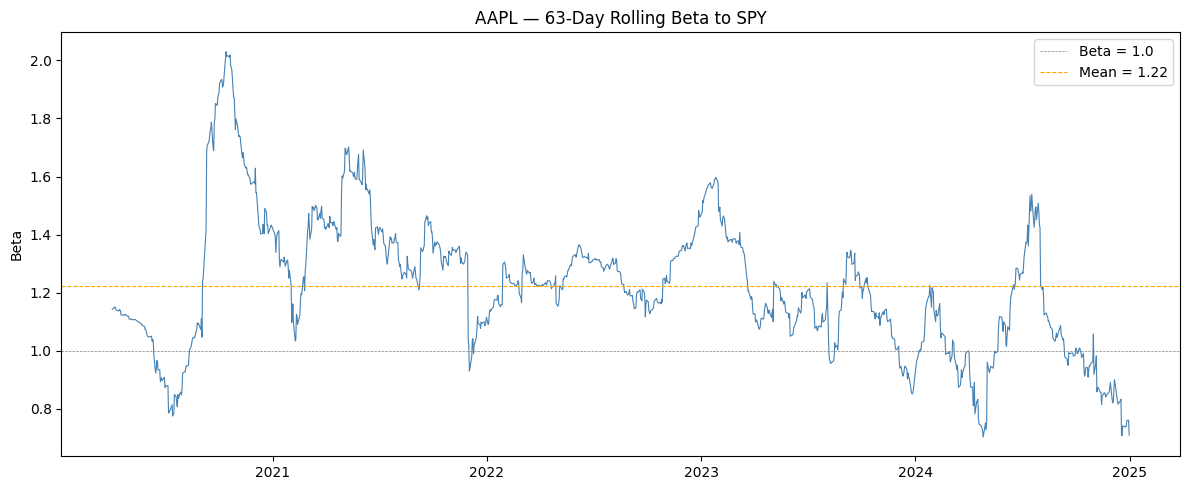

AAPL rolling beta range: 0.70 to 2.03
A static beta hides the regime changes underneath.


In [15]:
# 63-day rolling beta for AAPL
window = 63
rolling_cov = returns['AAPL'].rolling(window).cov(returns['SPY'])
rolling_var = returns['SPY'].rolling(window).var()
rolling_beta_aapl = (rolling_cov / rolling_var).dropna()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(rolling_beta_aapl, linewidth=0.8, color='steelblue')
ax.axhline(1.0, color='grey', linewidth=0.5, linestyle='--', label='Beta = 1.0')
ax.axhline(rolling_beta_aapl.mean(), color='orange', linewidth=0.8, linestyle='--',
           label=f'Mean = {rolling_beta_aapl.mean():.2f}')
ax.set_title(f'AAPL \u2014 {window}-Day Rolling Beta to SPY')
ax.set_ylabel('Beta')
ax.legend()
plt.tight_layout()
plt.show()

print(f'AAPL rolling beta range: {rolling_beta_aapl.min():.2f} to {rolling_beta_aapl.max():.2f}')
print('A static beta hides the regime changes underneath.')

Look at the spike around early 2020 — that's COVID. Correlations surged across the board and nearly every stock's beta converged toward 1.0 or above. A "diversified" portfolio built on static betas suddenly behaved like a single levered market bet. This is the scenario that breaks risk models.

In [16]:
# EXERCISE: Plot JPM's rolling beta on the same chart as AAPL.
# Which stock has more stable beta? Which one spiked harder during COVID?

# rolling_cov_jpm = returns['JPM'].rolling(window).cov(returns['SPY'])
# rolling_beta_jpm = (rolling_cov_jpm / rolling_var).dropna()
# fig, ax = plt.subplots(figsize=(12, 5))
# ax.plot(rolling_beta_aapl, label='AAPL', linewidth=0.8)
# ax.plot(rolling_beta_jpm, label='JPM', linewidth=0.8)
# ax.axhline(1.0, color='grey', linewidth=0.5, linestyle='--')
# ax.legend()
# ax.set_title('Rolling Beta Comparison: AAPL vs JPM')
# plt.tight_layout()
# plt.show()

## Section 7: Information Ratio — The Report Card for Active Managers

The Information Ratio answers the question every LP asks: **how much alpha are you generating per unit of active risk?**

```
IR = annualized alpha / tracking error
```

Where tracking error is the annualized std dev of the regression residuals. A PM who generates 3% alpha with 6% tracking error (IR = 0.5) is far better than one who generates 3% alpha with 15% tracking error (IR = 0.2). Same alpha, but the first delivers it consistently.

| IR | Rating | How rare |
|----|--------|----------|
| < 0 | Destroying value | ~40% of active managers |
| 0.0 - 0.3 | Below average | Common |
| 0.3 - 0.5 | Decent | Top quartile |
| 0.5 - 1.0 | Very good | Top decile |
| > 1.0 | Exceptional | Extremely rare over long periods |

Grinold & Kahn's **Fundamental Law of Active Management** decomposes IR into `IC * sqrt(breadth)` — your prediction skill times the square root of how many independent bets you make. This is why quant funds with tiny edge but massive breadth can beat concentrated stock pickers.

In [17]:
# Compute information ratio for each stock using 3-factor model
header = f'{"Stock":<6} {"Alpha (ann)":>12} {"Tracking Err":>13} {"IR":>8}'
print(header)
print('-' * 43)

for ticker in ['AAPL', 'JPM', 'XOM']:
    aligned_ir = pd.concat([returns[ticker] - daily_rf, factors], axis=1).dropna()
    y_ir = aligned_ir.iloc[:, 0]
    X_ir = sm.add_constant(aligned_ir[['MKT', 'SMB', 'HML']])
    m_ir = sm.OLS(y_ir, X_ir).fit()

    alpha_ann = m_ir.params.iloc[0] * TRADING_DAYS
    tracking_error = m_ir.resid.std() * np.sqrt(TRADING_DAYS)
    ir = alpha_ann / tracking_error if tracking_error > 0 else 0

    print(f'{ticker:<6} {alpha_ann:>11.2%} {tracking_error:>12.2%} {ir:>8.2f}')

Stock   Alpha (ann)  Tracking Err       IR
-------------------------------------------
AAPL         6.78%       16.82%     0.40
JPM         10.02%       17.75%     0.56
XOM         14.30%       23.95%     0.60


In [18]:
# EXERCISE: The Fundamental Law in action.
# A fundamental PM has IC = 0.10 and makes 30 bets/year.
# A quant fund has IC = 0.02 but makes 5000 bets/year.
# Who has the higher IR?

ic_fundamental, breadth_fundamental = 0.10, 30
ic_quant, breadth_quant = 0.02, 5000

ir_fundamental = ic_fundamental * np.sqrt(breadth_fundamental)
ir_quant = ic_quant * np.sqrt(breadth_quant)

print(f'Fundamental PM:  IR = {ic_fundamental} * sqrt({breadth_fundamental}) = {ir_fundamental:.2f}')
print(f'Quant fund:      IR = {ic_quant} * sqrt({breadth_quant}) = {ir_quant:.2f}')
print('The quant fund wins by breadth alone. This is why the industry has gone systematic.')

Fundamental PM:  IR = 0.1 * sqrt(30) = 0.55
Quant fund:      IR = 0.02 * sqrt(5000) = 1.41
The quant fund wins by breadth alone. This is why the industry has gone systematic.


## Section 8: Where To Go From Here

You now have the toolkit to decompose any stock or portfolio into factor exposures and genuine alpha. Run `python -m modules.module_3_factor_models` from the repo root to see the full analysis with residual diagnostics, or check out `factor_dashboard.py` for an interactive version.

Every number on your morning risk report — beta, factor loadings, R-squared, tracking error, IR — you can now compute from scratch and, more importantly, you know what it means when something looks off.

### Further Reading

- **FACTOR_MATH_GUIDE.md** (in this repo) — the theory behind everything in this notebook, no code
- **Grinold & Kahn**, *Active Portfolio Management* — the definitive reference on IR and the fundamental law
- **Andrew Ang**, *Asset Management* — bridges academic factor theory with how practitioners use it
- **Paleologo**, *Advanced Portfolio Management* — connects factor models to portfolio construction at institutional scale